In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([2e2, 2e2, 2e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)



In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:
## prepare deposit class
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=64, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="PCS")

## deposit density to cartesian grid
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')

Attempting to get derived variable: 0_Volume...	[DONE]



In [5]:
## different usages of power_spectrum1d method

# basic 
powerspectr_basic, k1d_basic, (KX_basic, KY_basic, KZ_basic, hat_var_basic) = depo.power_spectrum1d(density_cartesian)

# with zero-padding
powerspectr_padded, k1d_padded, (KX_padded, KY_padded, KZ_padded, hat_var_padded) = depo.power_spectrum1d(density_cartesian,
                                                          npads=6)

# with windowing
powerspectr_hann, k1d_hann, (KX_hann, KY_hann, KZ_hann, hat_var_hann) = depo.power_spectrum1d(density_cartesian,
                                                          window=scipy.signal.windows.hann)

energy (real space) = 1.9112e-02
energy (fourier space) = 1.9112e-02
energy (real space) = 1.9112e-02
energy (fourier space) = 1.9112e-02
energy (real space) = 1.9112e-02
energy (fourier space) = 4.3573e-02


Text(0.5, 0.95, 'Density field (cut box)')

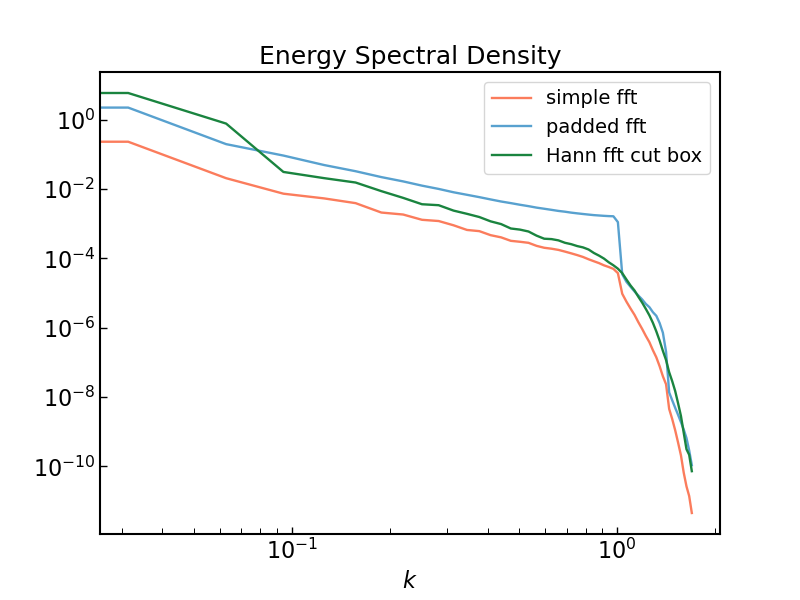

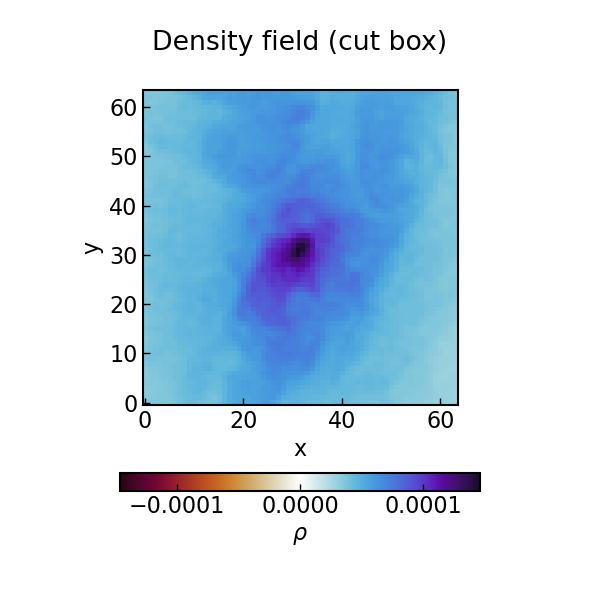

In [7]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(1,2, 100)

ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', color=reds[5],
        markerfacecolor='none', markersize=4, label=r'simple fft')

ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
        markerfacecolor='none', markersize=4, label=r'padded fft')

ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', color=greens[2],
        markerfacecolor='none', markersize=4, label=r'Hann fft cut box')

# ax.plot(tt, 1e3*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=1,fontsize=14)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
# ax.set_ylim(ymin=1e-25,ymax=1e-11)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)
# plt.show()

dens_cart_cut = density_cartesian[:,:,int(64//2)-1].value
vmax = np.max(dens_cart_cut)
vmin = -vmax
norm = Normalize(vmin=vmin,vmax=vmax)
# cmap = cmr.fall
cmap = cmr.fusion

fig, axes = plt.subplots(figsize=(6,6),sharex=True, sharey=True)

im1 = axes.imshow(
    dens_cart_cut, origin='lower', norm=norm, cmap=cmap)

axes.set_xlabel('x')
axes.set_ylabel('y')

cbar = fig.colorbar(im1, orientation='horizontal',shrink=0.75)
cbar.set_label(r'$\rho$')

fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (cut box)',y=0.95)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)
